In [1]:
import os
# Set the environment variable to disable hash randomization
os.environ['PYTHONHASHSEED'] = '0'
#If you find discrepancies between the UMAP and Leiden results, indicating reproducibility issues, 
#please refer to this link: https://github.com/scverse/scanpy/issues/1009 for potential solutions.
#https://umap-learn.readthedocs.io/en/latest/reproducibility.html
# set export OMP_NUM_THREADS=1 Multithreading can lead to reproducibility issues!!!
#Theoretically, minor differences in UMAP and inconsistencies in Leiden clustering do not affect their biological significance.
import scanpy as  sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import seaborn as sns
import scanpy.external as sce
import loompy
import harmonypy as hm
print('import successful')
#import scanpy as sc, scvi, torch

import successful


In [2]:
###global variable###

In [3]:
PCs = 10
res = 0.6
top_genes=2000
dataset = 'M-MG'
h5adpath = f''
celltypelist = ['Luminal epithelial cells','Basal epithelial cells','Proliferating epithelial cells','Keratinized epithelial cells']
vars_use=['sample']
NewCellType = {
    # ───────── Luminal lineages ─────────
    "LumSEC-Lac-Prime":      [0],
    "LumSEC-Progenitor":      [8],                 # ★ 怀疑 Luminal‑Progenitor
    "LumSEC-Progenitor-t2":    [12],        # 13 ★ 混合 Basal/Lum → MASC-like
    "Lum-Basal":         [13],
    'Lum-Krt1' : [11],
    # ───────── Basal lineages ──────────
    "Basal-Myo-Mature":  [1, 9],
    "Basal‑Progenitor":[17],               # ★ MASC-like / Basal‑Progenitor

    "MaSC-like":[2],
    # ───────── Stromal & Vascular ──────
    "Stromal-Fibroblast":[4],
    "Endothelial":       [10, 18],
    "Pericyte":          [14],

    # ───────── Immune ──────────────────
    "T-NK":              [3],
    "B-Cell":            [5],
    "Myeloid-MacDC":     [7, 15, 16],
    "Macrophage": [6]
}

update_cell_type = False
clusterlist = ['']
Featuregenes = ['Esr1','Epcam','Lalba','Top2a','Pgr','Prlr','Acta2','Elf5','Tcf4','Krt1','Ar','Pigr','Cd69','Adipoq','Lum','Vim','Ptprc','Lef1','Tpm2','Krt23','Krt10','Faah','Tm4sf1','Ppl','Wnt11','Krtdap','Sbsn','Dsp','Rab25','Aqp3','Shh','Atp1a1','Atp1b1','Procr','Col1a1','Krt8','Krt18','Krt14','Krt7','Krt5','Csn1s1','Csn2','Csn3','Xdh']
random.seed(2024)
np.random.seed(2024)
cells = 5000
doFeatureplot = True
runharmony = False
subset_celltype = True
do_subset_cluster = False
random_subset_cells = False
use_scvi=False

In [4]:
###################function###############

In [5]:
def run_qc(
    adata,
    species: str = "mouse",        # 只用于判断线粒体基因前缀
    min_genes: int = 200,
    max_genes: int = 6000,
    min_counts: int = 500,
    max_counts: int = 5e4,
    max_pct_mt: float = 10,
    expected_doublet_rate: float = 0.05,
    random_state: int = 0
):
    """
    质控流程：
      1. 计算线粒体百分比 / 总 UMI / 基因数等 QC 指标
      2. Scrublet 预测双胞
      3. 基于阈值 & 双胞标签过滤细胞
      4. 打印质控前后细胞数
    """
    # -------- 0. 记录初始细胞数 --------
    n_before = adata.n_obs

    # -------- 1. 标记线粒体基因并计算 QC 指标 --------
    mt_prefix = "MT-" if species.lower().startswith("human") else "mt-"
    adata.var["mt"] = adata.var_names.str.startswith(mt_prefix)
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        percent_top=None,
        log1p=False,
        inplace=True
    )

    # -------- 2. Scrublet 双胞检测 --------
    # Scrublet 需要原始计数矩阵 (adata.X)；若预处理改写过 X，请先用 adata.raw.X
    sce.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate,
        random_state=random_state
    )
    # Scrublet 结果列：'doublet_score' & 'predicted_doublet' 已写入 adata.obs

    # -------- 3. 细胞过滤 --------
    qc_filter = (
        (adata.obs.n_genes_by_counts >= min_genes) &
        (adata.obs.n_genes_by_counts <= max_genes) &
        (adata.obs.total_counts     >= min_counts) &
        (adata.obs.total_counts     <= max_counts) &
        (adata.obs.pct_counts_mt    <= max_pct_mt) &
        (~adata.obs.predicted_doublet)             # 去除 Scrublet 预测双胞
    )
    adata = adata[qc_filter].copy()  # 生成干净副本

    # -------- 4. 打印结果 --------
    n_after = adata.n_obs
    print(
        f"QC finished ➜ cells before: {n_before:,} | after: {n_after:,} "
        f"(removed: {n_before - n_after:,})"
    )

    return adata

In [6]:
def update_cell_annotations(adata, clustering_column, new_cell_type_dict, update_cell_type):
    if not update_cell_type:
        print("细胞注释更新被禁用")
        return adata


    cluster_to_celltype = {}

    for cell_type, clusters in new_cell_type_dict.items():
        for cluster in clusters:
            cluster_to_celltype[str(cluster)] = cell_type
    adata.obs['subtype'] = adata.obs[clustering_column].map(cluster_to_celltype)

    print("finish updata_cell_annotation")
    print(adata.obs['subtype'].value_counts())
    print(adata.obs['celltype'].value_counts())
    return adata

In [7]:
def run_harmony(adata,vars_use=vars_use):
    print('running harmony')
    pca_result = adata.obsm['X_pca']
    ho = hm.run_harmony(pca_result, adata.obs, vars_use,random_state=42)
    adata.obsm['X_pca_harmony'] = ho.Z_corr.T
    print('finished harmony')
    return adata

In [8]:
def random_subset(adata,n_cells):
    print(f"random subset cells {n_cells}")
    random_indices = np.random.choice(adata.n_obs, size=n_cells, replace=False)
    adata_sub = adata[random_indices, :]
    return adata_sub

In [9]:
def export_deg_result(adata):
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    data = []
    for group in groups:
        genes = result['names'][group]
        logfoldchanges = result['logfoldchanges'][group]
        pvals = result['pvals'][group]
        pvals_adj = result['pvals_adj'][group]
        for gene, lfc, pval, pval_adj in zip(genes, logfoldchanges, pvals, pvals_adj):
            data.append([group, gene, lfc, pval, pval_adj])
    df = pd.DataFrame(data, columns=['group', 'gene', 'logfoldchange', 'pval', 'pval_adj'])
    df1 = df[df['pval'] < 0.01]
    return df1

In [10]:
def run_scvi(adata,batch='stage',res=res):
    scvi.model.SCVI.setup_anndata(adata, batch_key=batch)
    model = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
    model.train()
    SCVI_LATENT_KEY = "X_scVI"
    adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
    sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
    sc.tl.leiden(adata,resolution = res)
    SCVI_MDE_KEY = "X_scVI_MDE"
    adata.obsm[SCVI_MDE_KEY] = scvi.model.utils.mde(adata.obsm[SCVI_LATENT_KEY], accelerator="cpu")
    return(adata)

In [11]:
def run_preprocess(adata,top_genes):
    adata.layers["counts"] = adata.X.copy()
    # Normalizing to median total counts
    sc.pp.normalize_total(adata)
    # Logarithmize the data
    sc.pp.log1p(adata)
    adata.raw=adata
    adata.layers["normalized"] = adata.X.copy()
    print('Finish normalized')
    sc.pp.highly_variable_genes(adata, n_top_genes=top_genes)
    sc.pl.highly_variable_genes(adata)
    print('Finish Varible genes')

In [12]:
def run_reduceDimension(ea,use_scvi,runharmony,PCs,res):
    import scanpy as  sc
    sc.pp.scale(ea,max_value=10)
    sc.tl.pca(ea,mask_var="highly_variable")
    sc.pl.pca_variance_ratio(ea,log = False)
    if use_scvi:   
        import os
        import tempfile
        import scanpy as sc
        import scvi
        import seaborn as sns
        import torch
        from scib_metrics.benchmark import Benchmarker
        scvi.settings.seed = 0
        print("Last run with scvi-tools version:", scvi.__version__)
        ea=run_scvi(ea)
        sc.pl.embedding(
            ea,
            basis=SCVI_MDE_KEY,
            color=['stage', "leiden",'celltype'],
            frameon=False,
            ncols=1,
            save=f'{dataset}_SCVI.png',
        )
    else:
        print('skip scvi')
    if runharmony:
        run_harmony(ea)
        sc.pp.neighbors(ea, use_rep='X_pca_harmony',n_pcs=PCs,random_state=42,n_neighbors=15)
        print('Finish neighbors')
    else:
        sc.pp.neighbors(ea,n_pcs=PCs,random_state=42)
        print('Finish neighbors')
    sc.tl.leiden(ea,resolution = res,random_state=42)
    print('Finish clustering')
    sc.tl.umap(ea,random_state=42)
    print('Finish UMAP')

In [13]:
def do_umap_plots(ea,dataset,Featuregenes,doFeatureplot):
    sc.settings.figdir = ''
    sc.pl.umap(
        ea,
        color=["celltype",'leiden'],
        # increase horizontal space between panels
        wspace=0.5,
        size=3,
    ncols=3,
    save=f'{dataset}_cluster.png',
    color_map='viridis'
    )

    if doFeatureplot:
        sc.pl.umap(
            ea,
            color=[*Featuregenes,'celltype'],
            # increase horizontal space between panels
            wspace=0.5,
            size=3,
        ncols=4,
        save=f'{dataset}_cluster_feature.png',gene_symbols='gene_name',
        color_map='plasma'
        )
        print('Featureplot Finished')
    else:
        print('666666')


In [14]:
def do_DEG(ea,dataset):
    #### Different gene test###
    sc.tl.rank_genes_groups(ea,groupby='leiden',method = 'wilcoxon')
    sc.pl.rank_genes_groups_dotplot(ea,groupby='leiden',n_genes=5,save=f'{dataset}_dotplot_leiden.png',min_logfoldchange=0.25,gene_symbols='gene_name')
      # 提取 DEG 结果（每个 cluster 的 top genes）
    deg_df = sc.get.rank_genes_groups_df(ea, group=None,gene_symbols='gene_name',pval_cutoff=0.01,log2fc_min=0.25)  # group=None 返回所有组别拼接的 DataFrame
    deg_df.to_csv(f'{dataset}_ranked_genes_for_annotation.csv', index=False)

In [15]:
def do_cell_barplot(ea, dataset):
    # 计算细胞类型比例
    celltype_counts = ea.obs.groupby(['stage', 'subtype']).size().unstack(fill_value=0)
    celltype_percentages = celltype_counts.div(celltype_counts.sum(axis=1), axis=0) * 100
    celltype_percentages_long = celltype_percentages.reset_index().melt(id_vars='stage', var_name='Celltype', value_name='Percentage')

    # 默认配色
    default_palette = ea.uns['subtype_colors']

    # 对 stage 按降序排列
    celltype_percentages = celltype_percentages.sort_index(ascending=False)
    times = celltype_percentages.index  # 更新排序后的 stage 顺序
    cell_types = celltype_percentages.columns
    colors = default_palette

    bottom = pd.Series([0] * len(times), index=times)

    # 设置图像比例为 8:4
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # 绘制横向柱状图，调整柱间距
    bar_width = 0.8  # 设置柱间距为 0
    for cell_type, color in zip(cell_types, colors):
        percentages = celltype_percentages[cell_type]
        ax.barh(times, percentages, left=bottom, color=color, label=cell_type, height=bar_width)  # 横向柱状图
        bottom += percentages

    # 设置标题和坐标轴标签
    ax.set_title(f'Percentage of Each Celltype Over Stage in {dataset}', fontsize=16)
    ax.set_xlabel('Percentage', fontsize=14)
    ax.set_ylabel('Stage', fontsize=14)

    # 设置图例
    ax.legend(title='Celltype', bbox_to_anchor=(1.05, 1), loc='upper left')

    # 调整布局
    plt.tight_layout()

    # 保存图表
    plt.savefig(f"{dataset}_raw_bar_plot.png", dpi=300)
    plt.savefig(f"{dataset}_raw_bar_plot.pdf")
    plt.show()

In [16]:
###########################

In [17]:
#h5adpath=f"../{dataset}.h5ad"

In [18]:
#h5adpath=f"D:/111/{dataset}_for_subset.h5ad"

In [19]:
h5adpath=f"D:/Data/{dataset}-track-bc.h5ad"
h5adpath

'D:/Data/M-MG-track-bc.h5ad'

In [20]:
ea=sc.read_h5ad(h5adpath)

D:\program\annaconda3\envs\py310\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [21]:
ea.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Gm1992,ENSMUSG00000089699,Gene Expression,mm10
Gm19938,ENSMUSG00000102331,Gene Expression,mm10
Gm37381,ENSMUSG00000102343,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
...,...,...,...
AC124606.1,ENSMUSG00000095523,Gene Expression,mm10
AC133095.2,ENSMUSG00000095475,Gene Expression,mm10
AC133095.1,ENSMUSG00000094855,Gene Expression,mm10
AC234645.1,ENSMUSG00000095019,Gene Expression,mm10


In [22]:
ea.var['gene_name']=ea.var_names
ea.var_names=ea.var['gene_ids']

In [23]:
#ea=run_qc(ea)

Finish normalized


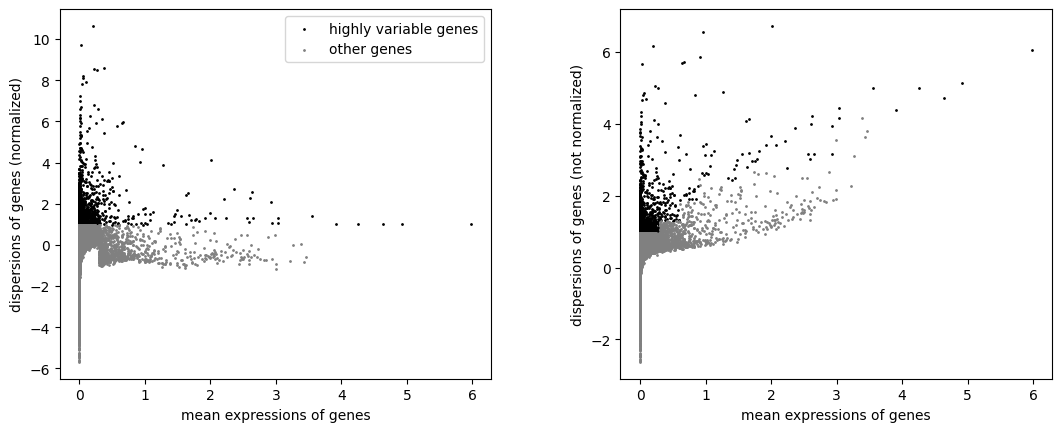

Finish Varible genes


In [24]:
run_preprocess(ea,top_genes=top_genes)

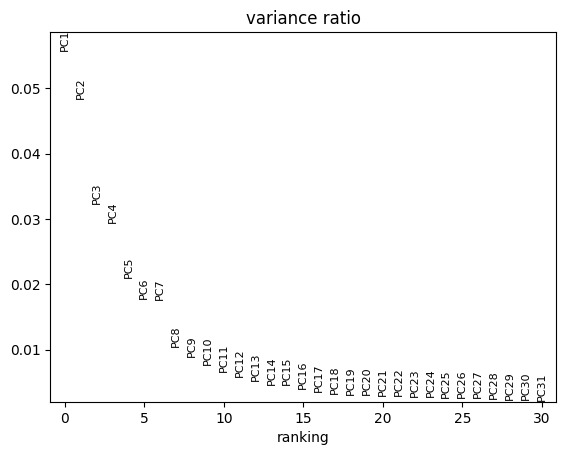

skip scvi
Finish neighbors


C:\Users\eatch\AppData\Local\Temp\ipykernel_29796\133347818.py:34: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ea,resolution = res,random_state=42)


Finish clustering
Finish UMAP


In [25]:
run_reduceDimension(ea,use_scvi=use_scvi,runharmony=runharmony,PCs=PCs,res=res)

In [26]:
if do_subset_cluster:
    ea = ea[~ea.obs['leiden'].isin(clusterlist)].copy()

In [27]:
ea = sc.read_h5ad(f"D:/Data/M-MG-track_for_DEG.h5ad")

In [28]:
ea

AnnData object with n_obs × n_vars = 15340 × 32285
    obs: 'bc', 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'subtype'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'connectivities', 'distances'

In [29]:
ea = update_cell_annotations(ea, clustering_column='leiden', new_cell_type_dict=NewCellType, update_cell_type=update_cell_type)

细胞注释更新被禁用


In [30]:
ea.var

,gene_ids,feature_types,genome,gene_name,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
gene_ids,,,,,,,,,,,,,,,
ENSMUSG00000051951,ENSMUSG00000051951,Gene Expression,mm10,Xkr4,False,1134,0.113411,92.754457,1775.0,False,8.628623e-02,0.793834,0.669112,0.052524,0.212965
ENSMUSG00000089699,ENSMUSG00000089699,Gene Expression,mm10,Gm1992,False,43,0.003003,99.725257,47.0,False,2.755416e-03,0.765977,0.616680,0.001683,0.037189
ENSMUSG00000102331,ENSMUSG00000102331,Gene Expression,mm10,Gm19938,False,200,0.014121,98.722126,221.0,False,1.036167e-02,0.360132,-0.147187,0.007051,0.068815
ENSMUSG00000102343,ENSMUSG00000102343,Gene Expression,mm10,Gm37381,False,0,0.000000,100.000000,0.0,False,1.000000e-12,NaN,NaN,0.000000,1.000000
ENSMUSG00000025900,ENSMUSG00000025900,Gene Expression,mm10,Rp1,False,2,0.000128,99.987221,2.0,False,5.531496e-05,-0.857429,-2.438839,0.000046,0.004038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,mm10,AC124606.1,False,0,0.000000,100.000000,0.0,False,1.000000e-12,NaN,NaN,0.000000,1.000000
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,mm10,AC133095.2,False,0,0.000000,100.000000,0.0,False,1.000000e-12,NaN,NaN,0.000000,1.000000
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,mm10,AC133095.1,False,0,0.000000,100.000000,0.0,False,1.000000e-12,NaN,NaN,0.000000,1.000000


In [31]:
ea.write(f'D:/Data/{dataset}_track_cleaned.h5ad')

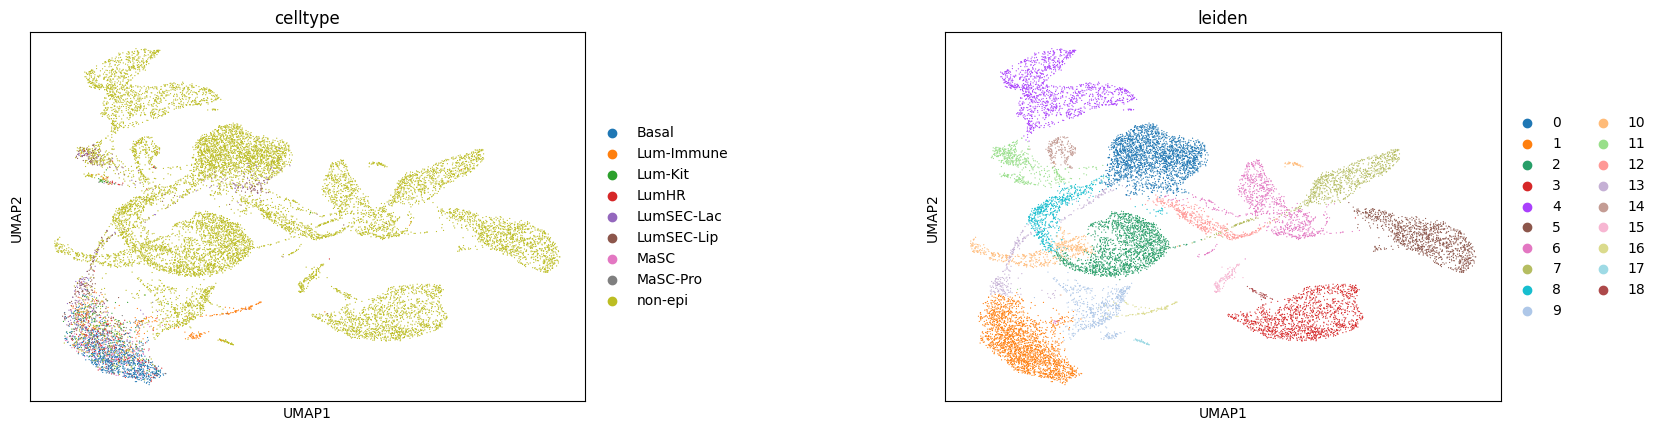

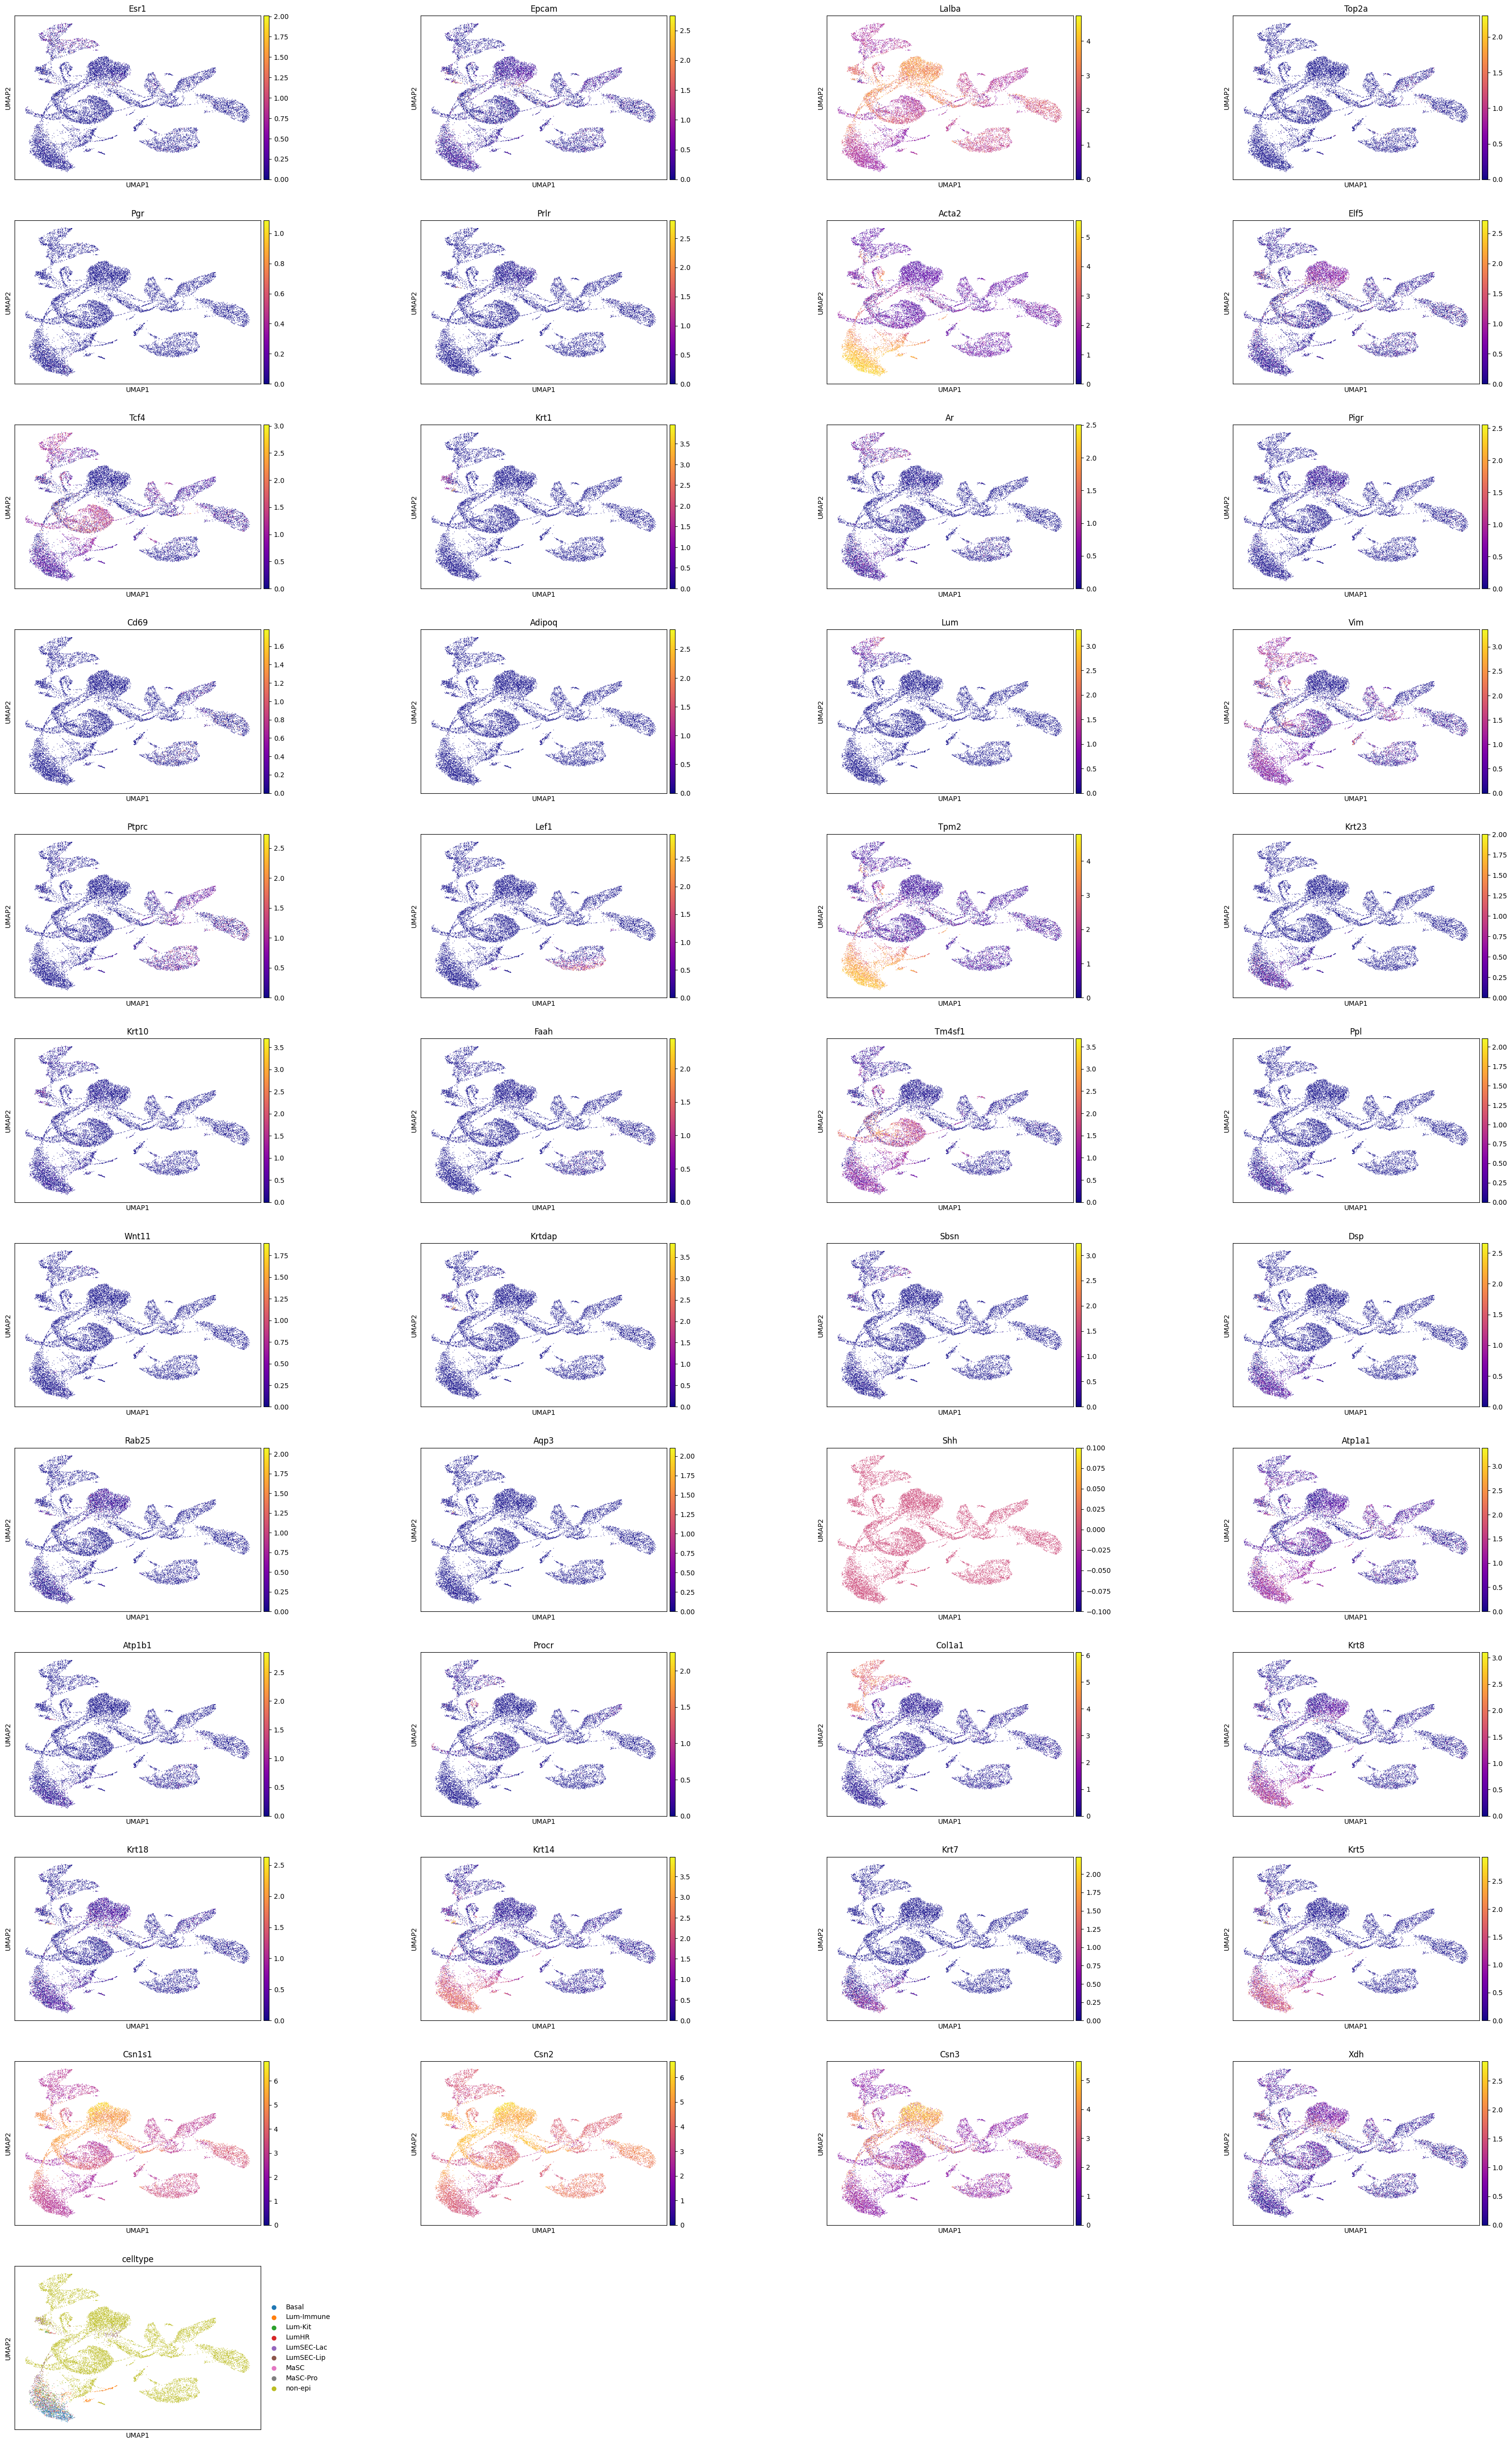

Featureplot Finished


In [32]:
do_umap_plots(ea=ea,dataset=dataset,Featuregenes=Featuregenes,doFeatureplot=doFeatureplot)

In [33]:
ea.raw = None


D:\program\annaconda3\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\program\annaconda3\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\program\annaconda3\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\program\annaconda3\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\program\annaconda3\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\program\annaconda3\env

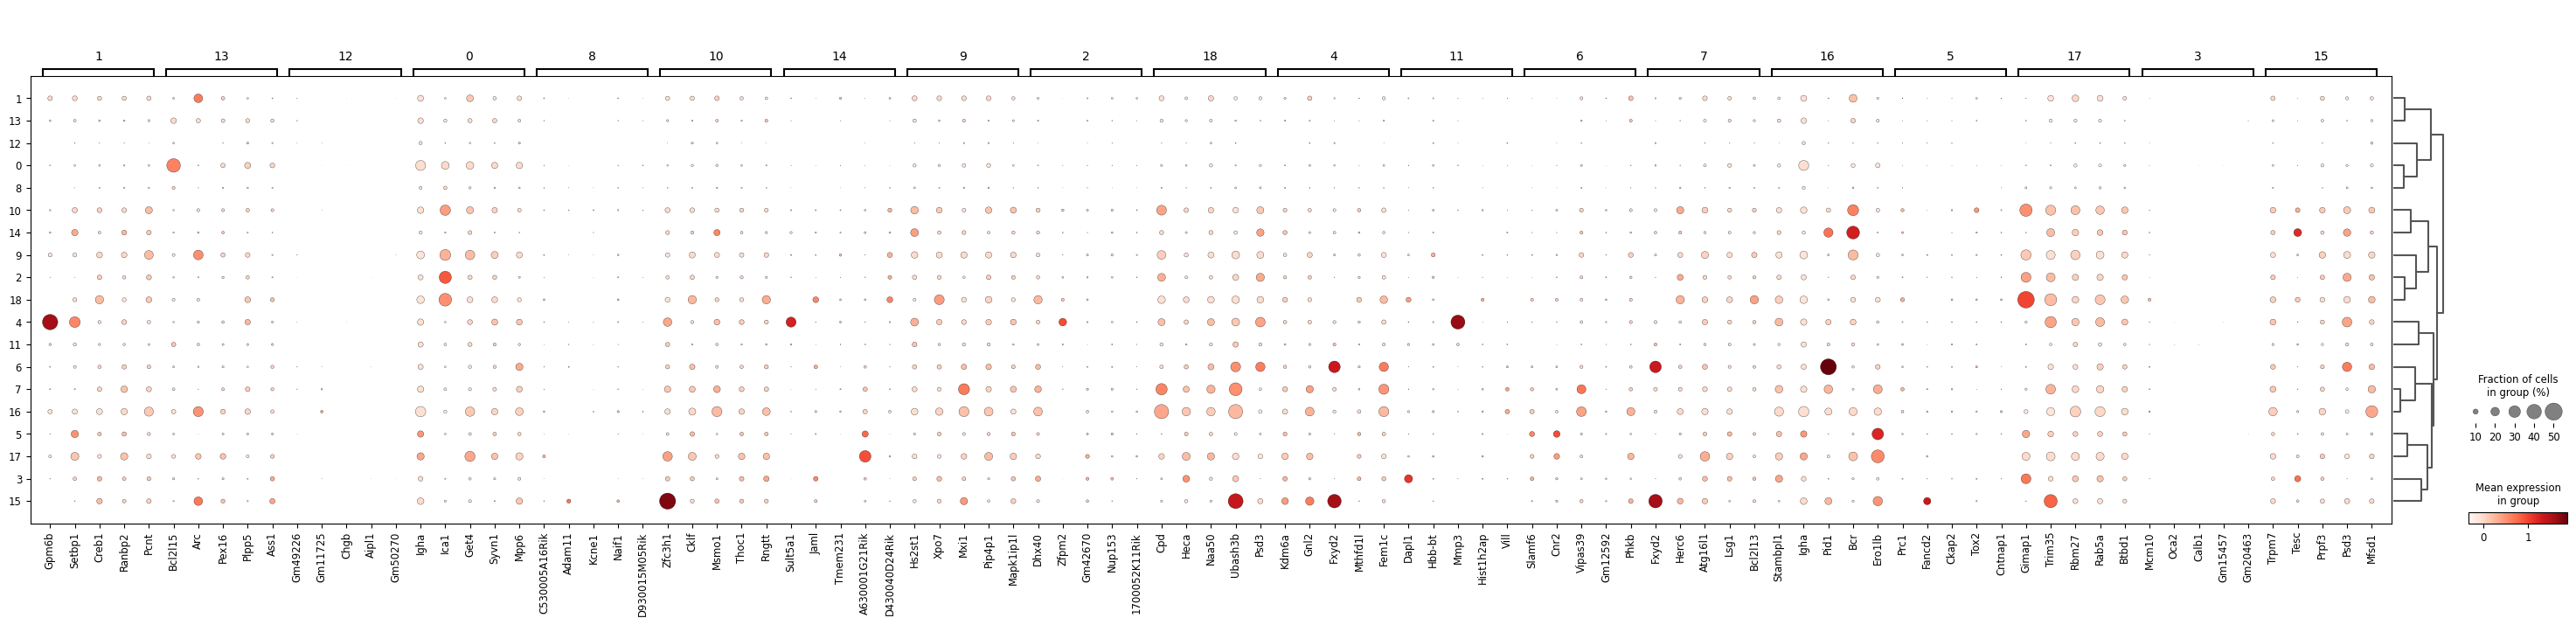

In [34]:
do_DEG(ea=ea,dataset=dataset)

In [35]:
do_cell_barplot(ea=ea,dataset=dataset)

KeyError: 'stage'